In [1]:
%pip install open3d

90.67s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 MB 5.0 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 6.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.8/79.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 5.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.3/217.3 kB 5.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 6.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 6.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.0/474.0 kB 5.9 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
import open3d as o3d
import numpy as np
# Load the PLY point cloud
pcd = o3d.io.read_point_cloud("/home/jpacker/sample_images/test_lidar/l515_bin1/cloud_0000.ply")
pts = np.asarray(pcd.points)
# Print a summary of the data (e.g., number of points, attributes)
print(pcd)


print("N points:", len(pts))
print("min: ", pts.min(0), "max: ", pts.max(0))

npy = np.load(("/home/jpacker/sample_images/test_lidar/l515_bin1/depth_0000.npy"))
print(f"shape: {npy.shape} dtype: {npy.dtype}")
print(f"min/max: {np.nanmin(npy), np.nanmax(npy)}")
# Visualize the point cloud in a 3D window


#doesn't work on server
#o3d.visualization.draw_geometries([pcd])


PointCloud with 2047676 points.
N points: 2047676
min:  [-0.67019127 -0.15758898 -1.08650005] max:  [ 0.27161066  0.3695443  -0.21425001]
shape: (1080, 1920) dtype: uint16
min/max: (np.uint16(0), np.uint16(5377))


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import time
import os

from ultralytics import YOLO, SAM

print('OpenCV:', cv2.__version__)
print('NumPy:', np.__version__)
print('Ultralytics YOLO ready')
print('Ultralytics SAM ready')

import torch
if torch.cuda.is_available():
    print(f'GPU available: {torch.cuda.get_device_name(0)}')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print('Apple MPS (Metal) available')
else:
    print('Running on CPU (slower but works fine)')

model_path = Path("/home/jpacker/BinPickingProject/vision_Notebook/runs/detect/train2/weights/best.pt")

print('\nSetup complete!')
print(f"model path is in {model_path}")

OpenCV: 4.10.0
NumPy: 2.3.5
Ultralytics YOLO ready
Ultralytics SAM ready
GPU available: NVIDIA RTX 6000 Ada Generation

Setup complete!
model path is in /home/jpacker/BinPickingProject/vision_Notebook/runs/detect/train2/weights/best.pt



0: 384x640 7 parts, 3.4ms
Speed: 1.6ms preprocess, 3.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
YOLO detected 7 objects. Passing boxes to SAM...

0: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 37.9ms
Speed: 3.9ms preprocess, 37.9ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)


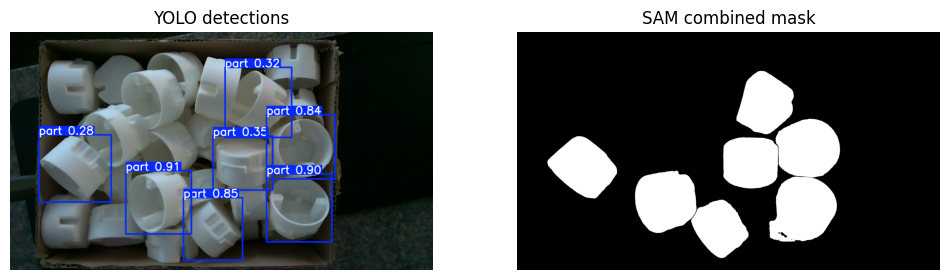

Detection 1: 0.9103
Detection 2: 0.9031
Detection 3: 0.8475
Detection 4: 0.8399
Detection 5: 0.3464
Detection 6: 0.3224
Detection 7: 0.2821


In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO, SAM

sam_path = "/home/jpacker/sam2.1_b.pt"
yolo_model = YOLO(model_path)
sam_model  = SAM(sam_path)

image_path = "/home/jpacker/sample_images/test_lidar/l515_bin1/rgb_0000.png"
image = cv2.imread(image_path)
h, w = image.shape[:2]

yolo_results = yolo_model(image)
bboxes = yolo_results[0].boxes.xyxy.cpu().numpy().astype(int)

combined_mask   = np.zeros((h, w), dtype=np.uint8)
per_object_masks = []

if len(bboxes) > 0:
    print(f"YOLO detected {len(bboxes)} objects. Passing boxes to SAM...")
    sam_results = sam_model(image, bboxes=bboxes)

    r = sam_results[0]
    if r.masks is not None:
        masks = (r.masks.data.cpu().numpy() * 255).astype(np.uint8)   # (N, H, W)
        per_object_masks = [masks[i] for i in range(masks.shape[0])]
        combined_mask = masks.max(axis=0)                              # (H, W)

    # save for the depth step
    np.save("/home/jpacker/sample_images/test_lidar/l515_bin1/combined_mask_0000.npy", combined_mask)


    # visualize
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(yolo_results[0].plot(img=image), cv2.COLOR_BGR2RGB))
    plt.title("YOLO detections"); plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(combined_mask, cmap='gray')
    plt.title("SAM combined mask"); plt.axis('off')
    plt.show()

for i, conf in enumerate(yolo_results[0].boxes.conf):
    print(f"Detection {i+1}: {conf.item():.4f}")

<h2>segmenting and cleaning depth</h2>


depth: (1080, 1920) uint16 0 5377
mask : (1080, 1920) uint8 [  0 255]
in-mask pixels: 398192
valid (masked + finite depth): 398192
coverage: 100.0%
depth range in mask: 1.042 – 1.534 m


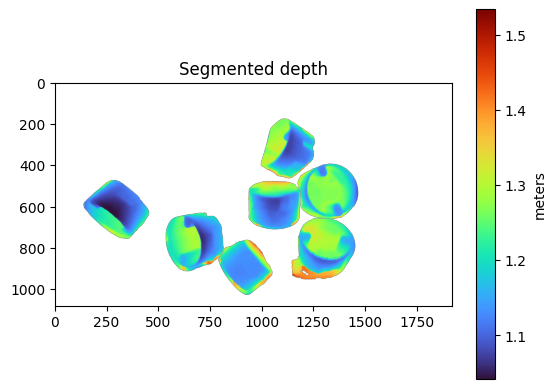

In [14]:
#load depth data
depth = np.load("/home/jpacker/sample_images/test_lidar/l515_bin1/depth_0000.npy")
mask = np.load("/home/jpacker/sample_images/test_lidar/l515_bin1/combined_mask_0000.npy")
assert depth.shape == mask.shape, f"{depth.shape} vs. {mask.shape}"
print("depth:", depth.shape, depth.dtype, depth.min(), depth.max())
print("mask :", mask.shape,  mask.dtype,  np.unique(mask))

depth_m   = depth.astype(np.float32) * 0.001        # mm -> m
mask_bool = mask > 0

valid = mask_bool & np.isfinite(depth_m) & (depth_m > 0)
depth_seg = np.where(valid, depth_m, np.nan).astype(np.float32)

np.save("/home/jpacker/sample_images/test_lidar/l515_bin1/depth_seg_0000.npy",
        depth_seg)

print(f"in-mask pixels: {mask_bool.sum()}")
print(f"valid (masked + finite depth): {valid.sum()}")
print(f"coverage: {100*valid.sum()/max(mask_bool.sum(),1):.1f}%")
print(f"depth range in mask: {np.nanmin(depth_seg):.3f} – {np.nanmax(depth_seg):.3f} m")

plt.imshow(depth_seg, cmap='turbo')
plt.colorbar(label='meters')
plt.title("Segmented depth")
plt.show()

In [ ]:
#get intrinsics from device
fx, fy, cx, cy = 1386.0, 1386.0, 960.0, 540.0

H, W = depth_seg.shape
u, v = np.meshgrid(np.arange(W), np.arange(H))

z = depth_seg
valid = np.isfinite(z) & (z > 0)

x = (u - cx) * z / fx
y = (v - cy) * z / fy

pts = np.stack([x[valid], y[valid], z[valid]], axis=1).astype(np.float64)

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pts)

o3d.io.write_point_cloud("partial.ply", pcd)